In [1]:
import numpy as np
import math
import kagglehub
import matplotlib.pyplot as plt

In [2]:
path = kagglehub.dataset_download("hojjatk/mnist-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/drew/.cache/kagglehub/datasets/hojjatk/mnist-dataset/versions/1


7


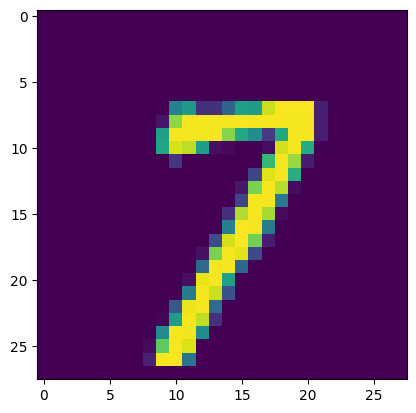

In [75]:
from pathlib import Path
path = Path(path)

train_image_path = path / "train-images.idx3-ubyte"
train_label_path = path /"train-labels.idx1-ubyte"
test_image_path = path / "t10k-images.idx3-ubyte"
test_label_path = path / "t10k-labels.idx1-ubyte"

train_label = np.fromfile(train_label_path, dtype=np.uint8)[8:]
train_image = np.fromfile(train_image_path, dtype=np.uint8)[16:].reshape(-1, 28, 28) / 255.0
test_label = np.fromfile(test_label_path, dtype=np.uint8)[8:]
test_image = np.fromfile(test_image_path, dtype=np.uint8)[16:].reshape(-1, 28, 28) / 255.0


data = {"train" : {"images" : train_image, "labels" : train_label}, "test" : 
        {"images" : test_image, "labels" : test_label}}


index = 3249   # select a random number 

img = data["train"]["images"][index]
#print(img) # Make sure pixel values are normalized
print(data["train"]["labels"][index])
plt.imshow(img)

In [25]:
rng = np.random.default_rng()

class DenseLayer:
    def __init__(self, num_neurons, num_weights_per_neuron):
        self.num_neurons = num_neurons
        self.num_weights_per_neuron = num_weights_per_neuron
        self.weights = rng.normal(loc=0.0,
                                  scale=np.sqrt(2 / num_weights_per_neuron),
                                  size=(num_weights_per_neuron, num_neurons))
        
        self.biases = np.zeros(num_neurons)

    def forward(self, inputs):
        self.inputs = inputs
        self.Z = (self.inputs @ self.weights) + self.biases 

        # Only return logits and apply activation function in MLP class
        return self.Z

    def backward(self, dZ):
        batch_size = self.inputs.shape[0]
        self.dW = self.inputs.T @ dZ / batch_size
        self.dB = np.sum(dZ, axis=0) / batch_size
        
        d_inputs = dZ @ self.weights.T
        return d_inputs


class MLP:
    def __init__(self):
        # Start with just 1 Hidden layer 
        self.hidden_layer = DenseLayer(64, 784)
        self.final_layer = DenseLayer(10, 64)


    def forward(self, inputs):
        self.inputs = inputs
        self.hidden_layer_out = self.hidden_layer.forward(self.inputs)
        self.act = np.maximum(0, self.hidden_layer_out)
        self.final_layer_out = self.final_layer.forward(self.act)
        
        return self.final_layer_out  

    def backward(self, probs, one_hot):
        batch_size = probs.shape[0]
        dZ2 = probs - one_hot
        dA1 = self.final_layer.backward(dZ2)
        # backprop through ReLU
        dZ1 = dA1 * (self.hidden_layer_out > 0)
        dX = self.hidden_layer.backward(dZ1)

        return dX




        

In [52]:
class Training:
    def __init__(self, model):
        self.model = model
        
    def get_loss(self, true_labels, logits):
        batch_size = len(true_labels)
        shifted = logits - np.max(logits, axis=1, keepdims=True)
        exp = np.exp(shifted)
        softmax_out = exp / np.sum(exp, axis=1, keepdims=True)
        self.probs = np.clip(softmax_out, 1e-12, 1.0)
        self.one_hots = np.zeros_like(self.probs)
        self.one_hots[np.arange(batch_size), true_labels] = 1
    
        losses = -np.sum(self.one_hots * np.log(self.probs), axis=1)
        self.loss = np.mean(losses) # we take the average loss over the whole batch
        
        return self.loss, self.probs, self.one_hots
        
    def training_loop(self, lr, num_epochs, train_data, batch_size=100):
        batch_images = train_data["images"].reshape(-1, 784)
        batch_labels = train_data["labels"].astype(int)
        
        for epoch in range(num_epochs):
            # shuffle data
            indices = np.arange(len(batch_images))
            rng.shuffle(indices)
            X = batch_images[indices]
            Y = batch_labels[indices]
            total_loss = 0
            total_correct = 0
            total_seen = 0
            
            for start in range(0, len(X), batch_size):
                # forward pass 
                end = start + batch_size
                inputs = X[start:end]
                true_labels = Y[start:end]
                logits = self.model.forward(inputs)
                # get loss
                loss, probs, one_hots = self.get_loss(true_labels, logits)
                # calc params (call backward)
                self.model.backward(probs, one_hots)
                # update weights 
                self.model.hidden_layer.weights -= self.model.hidden_layer.dW * lr
                self.model.hidden_layer.biases -= self.model.hidden_layer.dB * lr
                self.model.final_layer.weights  -= self.model.final_layer.dW * lr
                self.model.final_layer.biases -= self.model.final_layer.dB * lr

                # data
                preds = np.argmax(logits, axis=1)

                batch_size_actual = len(true_labels)
                total_loss += loss * batch_size_actual
                total_correct += np.sum(preds == true_labels)
                total_seen += batch_size_actual

            avg_loss = total_loss / total_seen
            accuracy = total_correct / total_seen
                
            # print stats 
            print("epoch:", epoch, "loss:", avg_loss, "accuracy:", accuracy) 

    def evaluate(self, test_data, batch_size=1000):
        X = test_data["images"].reshape(-1, 784)
        y = test_data["labels"].astype(int)
    
        total_loss = 0
        total_correct = 0
        total_seen = 0
    
        for start in range(0, len(X), batch_size):
            end = start + batch_size
    
            inputs = X[start:end]
            true_labels = y[start:end]
    
            logits = self.model.forward(inputs)
            loss, probs, one_hots = self.get_loss(true_labels, logits)
    
            preds = np.argmax(logits, axis=1)
    
            batch_size_actual = len(true_labels)
            total_loss += loss * batch_size_actual
            total_correct += np.sum(preds == true_labels)
            total_seen += batch_size_actual
    
        avg_loss = total_loss / total_seen
        accuracy = total_correct / total_seen
    
        print("test loss:", avg_loss, "test accuracy:", accuracy)
    
        return avg_loss, accuracy
                

In [67]:
# New model training run

model = MLP()

train_model = Training(model)

lr = 0.01
num_epochs = 1
train_data = data["train"]

train_model.training_loop(lr, num_epochs, train_data)

train_model.evaluate(data["test"])

epoch: 0 loss: 1.1523369212434211 accuracy: 0.6978833333333333
test loss: 0.6118704279798665 test accuracy: 0.8475


/var/folders/wz/v3rfj8z9745bbqv93zz4s31h0000gn/T/ipykernel_37559/3738964176.py:15: RuntimeWarning: overflow encountered in matmul
  self.Z = (self.inputs @ self.weights) + self.biases
/var/folders/wz/v3rfj8z9745bbqv93zz4s31h0000gn/T/ipykernel_37559/3738964176.py:15: RuntimeWarning: underflow encountered in matmul
  self.Z = (self.inputs @ self.weights) + self.biases
/var/folders/wz/v3rfj8z9745bbqv93zz4s31h0000gn/T/ipykernel_37559/3738964176.py:15: RuntimeWarning: invalid value encountered in matmul
  self.Z = (self.inputs @ self.weights) + self.biases
/var/folders/wz/v3rfj8z9745bbqv93zz4s31h0000gn/T/ipykernel_37559/3738964176.py:22: RuntimeWarning: overflow encountered in matmul
  self.dW = self.inputs.T @ dZ / batch_size
/var/folders/wz/v3rfj8z9745bbqv93zz4s31h0000gn/T/ipykernel_37559/3738964176.py:22: RuntimeWarning: underflow encountered in matmul
  self.dW = self.inputs.T @ dZ / batch_size
/var/folders/wz/v3rfj8z9745bbqv93zz4s31h0000gn/T/ipykernel_37559/3738964176.py:22: RuntimeWar

(np.float64(0.6118704279798665), np.float64(0.8475))

True label: 3
Predicted: 3


/var/folders/wz/v3rfj8z9745bbqv93zz4s31h0000gn/T/ipykernel_37559/3738964176.py:15: RuntimeWarning: overflow encountered in matmul
  self.Z = (self.inputs @ self.weights) + self.biases
/var/folders/wz/v3rfj8z9745bbqv93zz4s31h0000gn/T/ipykernel_37559/3738964176.py:15: RuntimeWarning: underflow encountered in matmul
  self.Z = (self.inputs @ self.weights) + self.biases
/var/folders/wz/v3rfj8z9745bbqv93zz4s31h0000gn/T/ipykernel_37559/3738964176.py:15: RuntimeWarning: invalid value encountered in matmul
  self.Z = (self.inputs @ self.weights) + self.biases


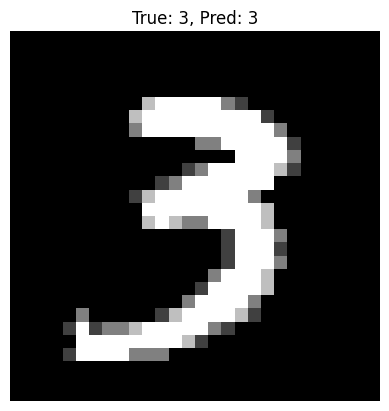

In [74]:
index = rng.integers(0, len(data["test"]["images"]))

img = data["test"]["images"][index]          # shape (28, 28)
x = img.reshape(1, 784)                      # shape (1, 784), batch of 1
true_label = data["test"]["labels"][index]

logits = model.forward(x)                    # shape (1, 10)
pred = np.argmax(logits, axis=1)[0]

print("True label:", true_label)
print("Predicted:", pred)

plt.imshow(img, cmap="gray")
plt.title(f"True: {true_label}, Pred: {pred}")
plt.axis("off")
plt.show()